In [11]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd


In [2]:

source = '/cosma5/data/durham/dc-pick2/simulations'

In [11]:
!tail -n 10 /cosma5/data/durham/dc-pick2/simulations/Hyades/nbody.log

         END RUN    TIME[Myr] =  626.52  TOFF/TIME/TTOT=      0.00000000    260.00000000    260.00000000  CPUTOT =   21.2  ERRTOT = 6.32360D-05  DETOT = 1.02914D-03


        0 INTEGRATION INTERVAL =  260.00    NIRR=          0 NIRRB=     120539 NREG=          0 NKS=          0


          PER TIME UNIT: NIRR= 0.00000D+00 NIRRB= 4.63612D+02 NREG= 0.00000D+00 NKS= 0.00000D+00
  MYDUMP     260.0000000000000      260                             1 
 comm.1_260                 
  Total CPU=    1270.851805061102     


In [158]:
# get paths for each snap file for each folder in experiment_path
def get_snaps_many(experiment_path):
    runs = !ls $experiment_path
    runs = np.sort(np.asarray(runs).astype(int))

    snaps = {}
    for run in runs:
        snaps[run] = !ls $experiment_path/$run/snap.40_*.h5part

    return runs, snaps

# get snaps in a file
def get_snaps(path):
    snaps = !ls $path/snap.40_*.h5part
    return snaps


In [166]:
Hyades_path = source + '/Hyades'

snaps = get_snaps(path)
print(snaps)

['/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_0.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_100.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_120.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_140.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_160.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_180.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_200.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_20.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_220.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_40.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_60.h5part', '/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_80.h5part']


In [15]:
path = source + '/Hyades/snap.40_60.h5part'
with h5py.File(path, 'r') as f:
    #f.visititems(print)
    print(list(f.keys()))

['Step#0', 'Step#1', 'Step#10', 'Step#100', 'Step#101', 'Step#102', 'Step#103', 'Step#104', 'Step#105', 'Step#106', 'Step#107', 'Step#108', 'Step#109', 'Step#11', 'Step#110', 'Step#111', 'Step#112', 'Step#113', 'Step#114', 'Step#115', 'Step#116', 'Step#117', 'Step#118', 'Step#119', 'Step#12', 'Step#120', 'Step#121', 'Step#122', 'Step#123', 'Step#124', 'Step#125', 'Step#126', 'Step#127', 'Step#128', 'Step#129', 'Step#13', 'Step#130', 'Step#131', 'Step#132', 'Step#133', 'Step#134', 'Step#135', 'Step#136', 'Step#137', 'Step#138', 'Step#139', 'Step#14', 'Step#140', 'Step#141', 'Step#142', 'Step#143', 'Step#144', 'Step#145', 'Step#146', 'Step#147', 'Step#148', 'Step#149', 'Step#15', 'Step#150', 'Step#151', 'Step#152', 'Step#153', 'Step#154', 'Step#155', 'Step#156', 'Step#157', 'Step#158', 'Step#159', 'Step#16', 'Step#17', 'Step#18', 'Step#19', 'Step#2', 'Step#20', 'Step#21', 'Step#22', 'Step#23', 'Step#24', 'Step#25', 'Step#26', 'Step#27', 'Step#28', 'Step#29', 'Step#3', 'Step#30', 'Step#31

In [16]:
with h5py.File(path, 'r') as f:
    step = f['Step#159']
    print(list(step.keys()))
    x = step['X1'][:]
    y = step['X2'][:]
    z = step['X3'][:]
    m = step['M'][:]
    #kw = step['KW'][:]
    nam = kw = step['NAM'][:] # starID
    print(dict(step.attrs))


['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
{'N_SINGLE': np.int32(8462), 'Time': np.float64(80.0)}


In [200]:
path = Hyades_path + '/snap.40_240.h5part'

with h5py.File(path, 'r') as f:
    for step in sorted(f.keys(), key=lambda k: f[k].attrs['Time']):
        keys = list(f[step].keys())
        n = len(f[step]['M'])
        t = f[step].attrs['Time']
        print(f"{step}: time:{t}, {n} particles, fields: {keys}")

Step#0: time:240.125, 8460 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#1: time:240.25, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#2: time:240.375, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#3: time:240.5, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#4: time:240.625, 8458 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#5: time:240.75, 8456 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#6: time:240.875, 8462 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#7: time:241.0, 8458 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3', 'X1', 'X2', 'X3']
Step#8: time:241.125, 8460 particles, fields: ['Binaries', 'M', 'NAM', 'POT', 'V1', 'V2', 'V3'

In [279]:
def get_glob_df(run_path):
    glob_path = run_path + '/global.30'
    return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
    

def get_snap_times(run, snap_path, Myr_per_NB):
    with h5py.File(snap_path, 'r') as f:
        
        df = pd.DataFrame()
        df['Step'] = sorted(f.keys(), key=lambda k: f[k].attrs['Time'])
        df['Time[NB]'] = [f[step].attrs['Time'] for step in df['Step']]
        df['Time[Myr]'] = df['Time[NB]'] * Myr_per_NB
        df['snap_path'] = snap_path
        df["snap_name"] = df["snap_path"].str.split("/").str[-1]
        df['run'] = run
        return df

def get_run_snap_times(run, snaps, glob_df):
    Myr_per_NB = glob_df['TIME[Myr]'].iloc[-1] / glob_df['TIME[NB}'].iloc[-1]

    dfs = []
    for snap_path in snaps:
        dfs.append(get_snap_times(run, snap_path, Myr_per_NB))

    return pd.concat(dfs, ignore_index=True).sort_values("Time[Myr]")


def get_experiment_snap_times(experiment_path):
    runs, snaps = get_snaps_many(experiment_path)

    dfs = []
    for run in runs:
        run_path = f'{experiment_path}/{run}'
        glob_df = get_glob_df(run_path)

        dfs.append(get_run_snap_times(run, snaps[run], glob_df))

    return pd.concat(dfs, ignore_index=True).sort_values("Time[Myr]")
        
    
        

In [222]:
Hyades_path = source + '/Hyades'
glob_path = Hyades_path + '/global.30'
df_glob = pd.read_csv(glob_path, sep=r"\s+", index_col=False)

snaps = get_snaps(Hyades_path)

snap_df = get_run_snap_times('Hyades', snaps, df_glob)
snap_df

/tmp/ipykernel_3737168/3125247750.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df_glob = pd.read_csv(glob_path, sep=r"\s+", index_col=False)


,Step,Time[NB],Time[Myr],snap_path,snap_name,run
0,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
1,Step#1,0.125,0.301211,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
2,Step#2,0.250,0.602422,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
3,Step#3,0.375,0.903633,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
4,Step#4,0.500,1.204844,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
...,...,...,...,...,...,...
1596,Step#155,259.500,625.313983,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1597,Step#156,259.625,625.615194,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1598,Step#157,259.750,625.916405,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades
1599,Step#158,259.875,626.217616,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_240.h5part,Hyades


In [305]:
def find_times_Myr(snap_df, run, times):
    mask = snap_df['run'] == run

    idx = np.searchsorted(snap_df.loc[mask, 'Time[Myr]'], times)    
    idx[idx >= len(snap_df[mask])] = len(snap_df[mask]) - 1
    
    return snap_df[mask].iloc[idx].reset_index(drop=True)

def get_step(snap_path, step):
    df = pd.DataFrame()

    with h5py.File(snap_path, 'r') as f:
        s = f[step]
        df["M"] = s["M"][:]
        df["NAM"] = s["NAM"][:]
        df["POT"] = s["POT"][:]
        df["Vx"] = s["V1"][:]
        df["Vy"] = s["V2"][:]
        df["Vz"] = s["V3"][:]
        df["X"] = s["X1"][:]
        df["Y"] = s["X2"][:]
        df["Z"] = s["X3"][:]
        df.attrs['Time'] = s.attrs["Time"] * Myr_per_Nbody

        return df
        

def plot_step(fig, ax, snap_path, step, Myr_per_Nbody, offset=200, label=None,
              hidexlbl=False, hideylbl=False, hidetitle=False):   
    
    stepdf = get_step(snap_path, step)
    #print(stepdf)
        
    #com_x = np.average(x, weights=m)
    #com_z = np.average(z, weights=m)

    com_x = np.median(stepdf["X"])
    com_y = np.median( stepdf["Y"])

    hist, xedges, yedges = np.histogram2d(stepdf['X'] - com_x, stepdf['Y'] - com_y, bins=100,
                                          range=[[-offset, offset], [-offset, offset]])
    ax.imshow(
    hist.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='gray_r',
    norm=LogNorm(),
    label=label
    )
    
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    
    if not hidetitle: ax.set_title(f'{stepdf.attrs['Time']:.1f} Myr')
    if not hidexlbl: ax.set_xlabel('X / pc')
    if not hideylbl: ax.set_ylabel('Y / pc')
    if label is not None: ax.text(-0.8*offset, 0.8*offset, label)
    ax.set_xlim(-offset, offset)
    ax.set_ylim(- offset, offset)
    ax.set_aspect('equal')

In [272]:
times = [0,100,200,300,400,500]
run = 'Hyades'
timesdf = find_times_Myr(snap_df, run, times)
timesdf

,Step,Time[NB],Time[Myr],snap_path,snap_name,run
0,Step#0,0.0,0.000000,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_0.h5part,Hyades
1,Step#11,41.5,100.002044,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_40.h5part,Hyades
2,Step#23,83.0,200.004087,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_80.h5part,Hyades
3,Step#35,124.5,300.006131,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_120.h5part,Hyades
4,Step#47,166.0,400.008174,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_160.h5part,Hyades
5,Step#59,207.5,500.010218,/cosma5/data/durham/dc-pick2/simulations/Hyade...,snap.40_200.h5part,Hyades


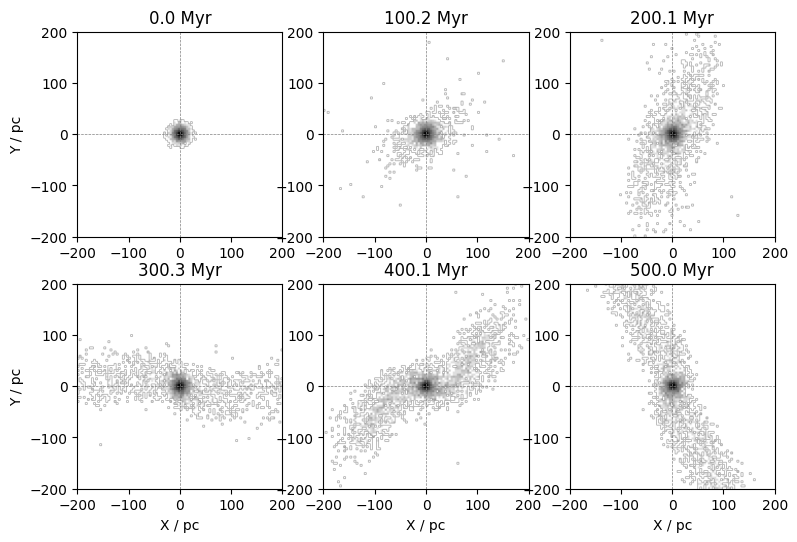

In [296]:
pltx = 3
plty = 2
offset = 200

fig, axes = plt.subplots(plty, pltx, figsize=(9, 6))
for i, row in timesdf.iterrows():
    x = i % pltx
    y = i // pltx
    ax = axes[y][x]

    Myr_per_Nbody = 1 if row['Time[NB]'] == 0 else row['Time[Myr]'] / row['Time[NB]']

    plot_step(fig, ax, row['snap_path'], row['Step'], Myr_per_Nbody, offset, 
              hidexlbl=y==0, hideylbl=x>0)

    

plt.show()





## Concentration

In [301]:
conc_path = source + '/Concentration'


runs, snaps = get_snaps_many(conc_path)

conc_snapdf = get_experiment_snap_times(conc_path)

conc_snapdf

/tmp/ipykernel_3737168/2482507827.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3737168/2482507827.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3737168/2482507827.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3737168/2482507827.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  return pd.read_csv(glob_path, sep=r"\s+", index_col=False)
/tmp/ipykernel_3737168/2482507827.py:3: ParserWarning: Length of header or names does not match length o

,Step,Time[NB],Time[Myr],snap_path,snap_name,run
0,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_0.h5part,2
3530,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_0.h5part,6
1777,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_0.h5part,4
9524,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_0.h5part,12
6948,Step#0,0.000,0.000000,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_0.h5part,10
...,...,...,...,...,...,...
3528,Step#150,218.875,626.629319,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_200.h5part,4
6947,Step#71,229.000,626.635939,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_220.h5part,8
5113,Step#142,197.875,626.981710,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_180.h5part,6
3529,Step#151,219.000,626.987189,/cosma5/data/durham/dc-pick2/simulations/Conce...,snap.40_200.h5part,4


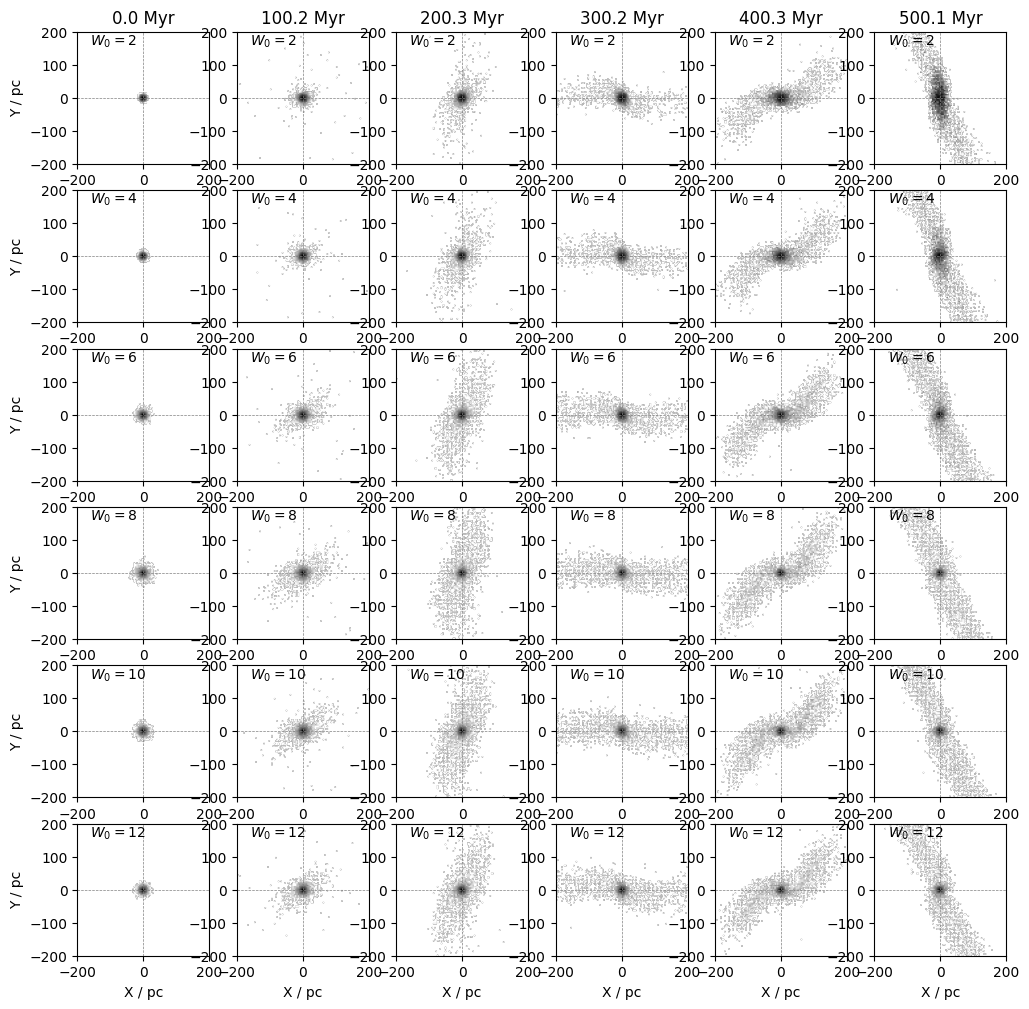

In [312]:
times = [0,100,200,300,400,500]
fig, axes = plt.subplots(len(times), len(runs), figsize=(12, 12))


for i, run in enumerate(runs):
    timesdf = find_times_Myr(conc_snapdf, run, times)
    
    for j, row in timesdf.iterrows():
        ax = axes[i][j]
        Myr_per_Nbody = 1 if row['Time[NB]'] == 0 else row['Time[Myr]'] / row['Time[NB]']
        plot_step(fig, ax, row['snap_path'], row['Step'], Myr_per_Nbody, offset, hidetitle=i>0, hideylbl=j>0,
                  label=fr'$W_0={{{run}}}$')


plt.show()


